<a href="https://colab.research.google.com/github/rathore-rl1lmg1/Cooding-Playground/blob/main/mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch import nn
import torch.optim as optim

In [ ]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 127MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 63.9MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 96.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.92MB/s]


In [ ]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

In [ ]:
X = training_data.data.float().view(-1, 784) / 255.0
y = torch.nn.functional.one_hot(training_data.targets, 10).float()

In [ ]:
print(X.shape)
print(y.shape)

torch.Size([60000, 784])
torch.Size([60000, 10])


In [ ]:
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)       \
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NeuralNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_losses = []
test_accuracies = []

In [ ]:
epochs = 5
total = 0
correct = 0
for epoch in range(epochs):
    model.train()

    running_loss = 0

    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    epoch_loss = running_loss / len(train_dataloader)
    train_losses.append(epoch_loss)
    with torch.no_grad():     # tell no gradient to take
        for images, labels in test_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] "f"Loss: {epoch_loss:.4f} "f"Accuracy: {accuracy:.2f}%")

Epoch [1/5] Loss: 0.3512 Accuracy: 94.37%
Epoch [2/5] Loss: 0.1491 Accuracy: 95.42%
Epoch [3/5] Loss: 0.1010 Accuracy: 95.86%
Epoch [4/5] Loss: 0.0760 Accuracy: 96.03%
Epoch [5/5] Loss: 0.0596 Accuracy: 96.26%


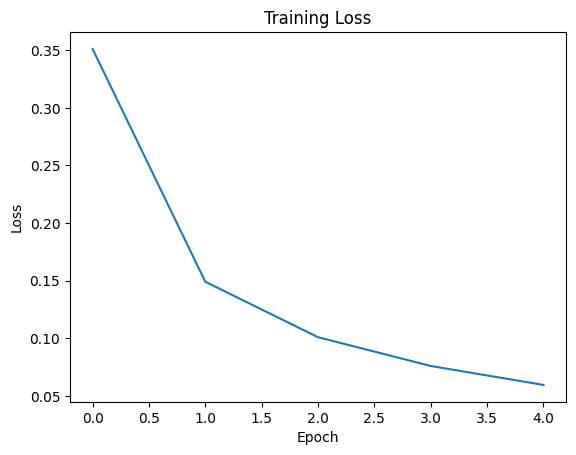

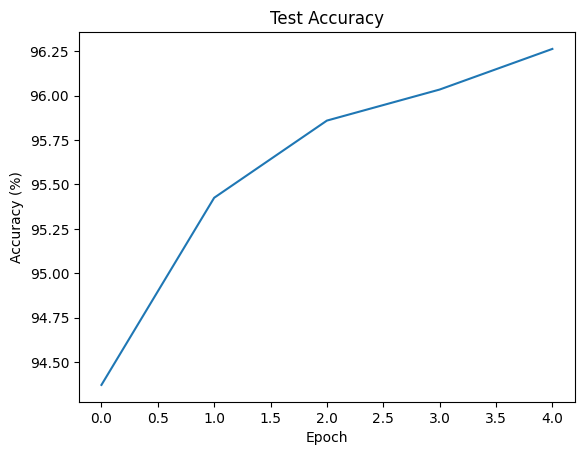

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(test_accuracies)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.show()